# Modélisation des ventes par magasin - Prévision de la demande

## Introduction

L'exploration des données nous a permis de comprendre les disparités entre magasins, 
les patterns temporels et l'impact des événements sur les ventes. On passe maintenant 
à la modélisation pour construire un modèle capable de prédire les ventes futures 
par magasin et par produit.

Contrairement à la partie globale qui travaille sur des ventes agrégées, ici on garde 
le détail par produit et par magasin. Cela rend les données plus irrégulières mais 
permet à Sophie Martin de savoir exactement quoi commander dans son magasin.

Les étapes sont :
1. Feature engineering : préparer les données pour le ML
2. Split temporel : séparer train et test dans le temps
3. Comparaison des modèles : choisir le meilleur
4. Analyse du biais : critère de choix principal pour la supply chain
5. Export : sauvegarder le modèle pour le Streamlit

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import lightgbm as lgb
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')
calendar["date"] = pd.to_datetime(calendar["date"])

## Feature engineering

In [94]:
day_cols = [c for c in sales.columns if c.startswith('d_')]
print(f"Lignes si on met tout le dataset : {sales.shape[0] * len(day_cols):,}")
print(f"Lignes avec 270 jours : {sales.shape[0] * 270:,}")

# On garde les 270 derniers jours
day_cols_recent = day_cols[-270:]

# Format long : 1 ligne = 1 produit x 1 magasin x 1 jour
df_long = sales[['item_id', 'store_id', 'state_id'] + day_cols_recent].melt(
    id_vars=['item_id', 'store_id', 'state_id'],
    var_name='d',
    value_name='sales'
)

# Ajout des infos du calendrier
df_long = df_long.merge(
    calendar[['d', 'date', 'event_name_1']],
    on='d', how='left'
)

# Tri chronologique: obligatoire avant de calculer les lags
df_long = df_long.sort_values(['item_id', 'store_id', 'date']).reset_index(drop=True)

# Variables temporelles
df_long['dayofweek']    = df_long['date'].dt.dayofweek
df_long['month']        = df_long['date'].dt.month
df_long['week_of_year'] = df_long['date'].dt.isocalendar().week.astype(int)

# Encodage des events
# on avait essayé has_event en binaire mais elle valait 1 partout
df_long['event_enc'] = LabelEncoder().fit_transform(
    df_long['event_name_1'].fillna('No_event')
)

# Encodage des variables catégorielles
le = LabelEncoder()
df_long['store_id_enc'] = le.fit_transform(df_long['store_id'])
df_long['state_id_enc'] = le.fit_transform(df_long['state_id'])
df_long['item_id_enc']  = le.fit_transform(df_long['item_id'])

# Lags
df_long['lag_1']  = df_long.groupby(['item_id', 'store_id'])['sales'].shift(1)
df_long['lag_7']  = df_long.groupby(['item_id', 'store_id'])['sales'].shift(7)
df_long['lag_28'] = df_long.groupby(['item_id', 'store_id'])['sales'].shift(28)

# Rolling mean et std sur 7 jours
df_long['rolling_mean_7'] = df_long.groupby(
    ['item_id', 'store_id'])['sales'].shift(1).rolling(7).mean()
df_long['rolling_std_7'] = df_long.groupby(
    ['item_id', 'store_id'])['sales'].shift(1).rolling(7).std()

# snap non retenu : programme d'aide alimentaire, impact difficile à mesurer
df_long = df_long.dropna()

print(f"Feature engineering terminé : {df_long.shape[0]} lignes, {df_long.shape[1]} colonnes")

Lignes si on met tout le dataset : 59,181,090
Lignes avec 270 jours : 8,232,300
Feature engineering terminé : 670780 lignes, 19 colonnes


## 3. Analyse des features

Avant d'entraîner les modèles on analyse la corrélation de chaque feature avec les ventes pour justifier nos choix. C'est une bonne pratique en ML, en effet on ne garde pas des variables au hasard.

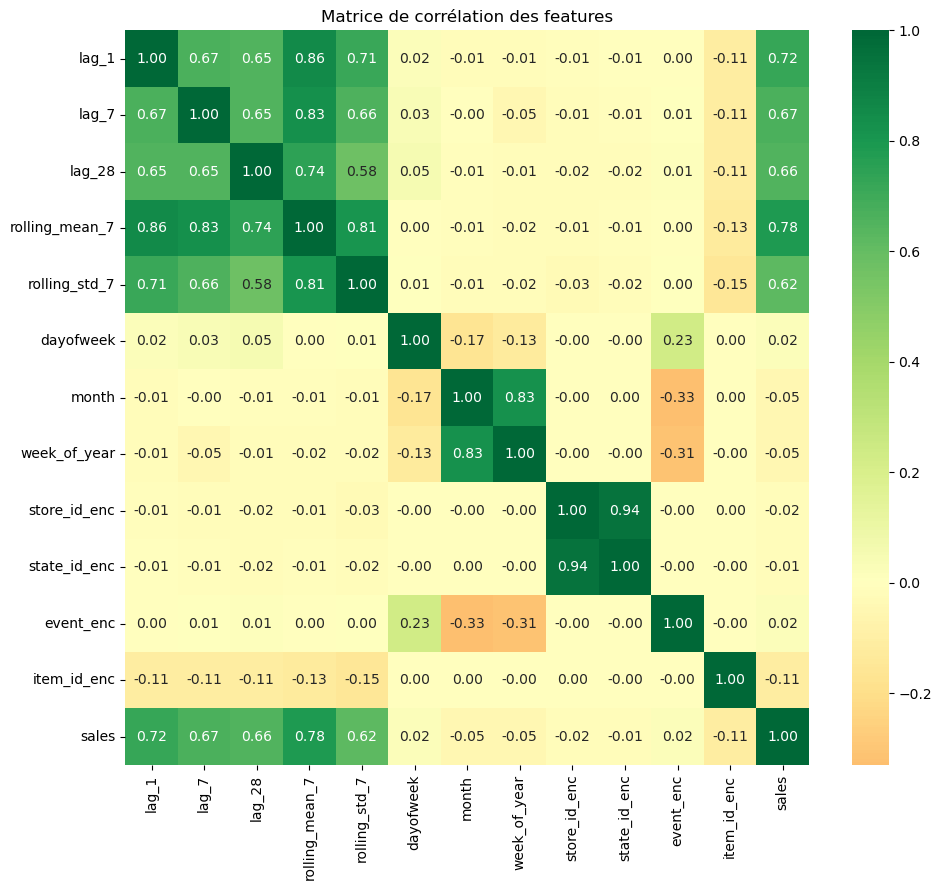

rolling_mean_7    0.784786
lag_1             0.724349
lag_7             0.672386
lag_28            0.655599
rolling_std_7     0.619575
dayofweek         0.021826
event_enc         0.021440
state_id_enc     -0.012736
store_id_enc     -0.016184
month            -0.045122
week_of_year     -0.051420
item_id_enc      -0.106723
Name: sales, dtype: float64


In [97]:
features_num = ['lag_1', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_std_7',
                'dayofweek', 'month', 'week_of_year',
                'store_id_enc', 'state_id_enc', 'event_enc', 'item_id_enc', 'sales']

matrice = df_long[features_num].corr()

plt.figure(figsize=(10, 9))
sns.heatmap(matrice, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matrice de corrélation des features')
plt.tight_layout()
plt.show()

print(matrice['sales'].drop('sales').sort_values(ascending=False))

**Interprétation de la matrice de corrélation :**

Les cinq features les plus corrélées avec les ventes sont `rolling_mean_7` (0.78), 
`lag_1` (0.72), `lag_7` (0.67), `lag_28` (0.66) et `rolling_std_7` (0.62). 
L'historique récent est de loin le meilleur prédicteur des ventes futures.

`lag_1` est plus corrélé avec les ventes (0.72) que `lag_7` (0.67) et sa corrélation 
avec `lag_7` est de 0.67, insuffisante pour le considérer redondant. On le garde.

`rolling_std_7` avec une corrélation de 0.62 apporte une information sur la 
variabilité des ventes récentes, complémentaire à `rolling_mean_7`. On le garde.

`event_enc` a une corrélation faible (0.02) car sur les 270 derniers jours 
presque tous les jours ont un event dans le calendrier M5. Cette feature reste 
dans le modèle car Memorial Day et Father's Day ont des impacts forts et différents 
selon le magasin comme montré dans l'exploration.

`store_id_enc` et `item_id_enc` ont des corrélations quasi nulles mais sont 
indispensables pour que le modèle différencie les magasins et les produits entre eux. 
L'information magasin est déjà captée indirectement par les lags calculés par magasin.

Features retirées après analyse :
- `state_id_enc` : corrélée à 0.94 avec `store_id_enc`, redondante
- `week_of_year` : corrélée à 0.59 avec `month`, redondante

**Features finales retenues pour le modèle :**
`dayofweek`, `month`, `lag_1`, `lag_7`, `lag_28`, `rolling_mean_7`, 
`rolling_std_7`, `store_id_enc`, `event_enc`, `item_id_enc`

**Note sur `has_event` :** on avait d'abord créé une variable binaire `has_event`. 
En faisant `print(df_long['has_event'].value_counts())` on a découvert qu'elle valait 
1 partout sur la période analysée. La corrélation était NaN. On l'a remplacée par 
`event_enc` qui encode le nom précis de l'événement, ce qui est beaucoup plus informatif.

## 2. Train-Test Split

Dans nos cours de ML on utilise train_test_split(X, y) qui mélange aléatoirement les données. Ici on ne peut pas faire ça car nos données sont des séries temporelles, si on mélange les dates, le modèle apprend sur des données futures et prédit le passé, ce qui n'a aucun sens.

On coupe donc manuellement dans le temps avec 80% pour entraîner et 20% pour tester. Le ratio 80/20 est la convention classique en ML.

Train : (37200, 10) ; Test : (9300, 10)
Période train : 2011-03-09 au 2016-05-08
Période test  : 2011-03-09 au 2016-05-08


On obtient train et test avec exactement les mêmes dates, ce qui n'a aucun sens. 
Le problème vient de la structure du dataset : les données sont triées par 
produit × magasin × jour. Un split par nombre de lignes coupe donc au milieu 
des produits et non dans le temps, le modèle voit le futur pendant l'entraînement, 
c'est ce qu'on appelle une fuite temporelle.

En cours on nous explique qu'on ne peut pas mélanger aléatoirement des données 
temporelles. Ici c'est encore plus contraignant car même un split ordonné 
par index ne fonctionne pas.

Dans la littérature sur la prévision, Hyndman & Athanasopoulos recommandent 
de toujours respecter l'ordre chronologique pour éviter cette fuite. 
La compétition M5 sur laquelle on travaille utilise d'ailleurs un horizon 
de test de 28 jours comme standard d'évaluation.

On applique donc la même logique : on entraîne sur tout sauf les 28 derniers 
jours, et on teste sur ces 28 jours.

In [99]:
# Split temporel par date: on coupe dans le temps pas dans les lignes
cutoff  = df_long['date'].max() - pd.Timedelta(days=28)
train   = df_long[df_long['date'] <= cutoff]
test    = df_long[df_long['date'] >  cutoff]

X_train = train[features]
X_test  = test[features]
y_train = train['sales']
y_test  = test['sales']

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Période train :", train['date'].min().date(), "au", train['date'].max().date())
print("Période test  :", test['date'].min().date(),  "au", test['date'].max().date())

Train : (548820, 10) | Test : (121960, 10)
Période train : 2015-09-24 au 2016-03-27
Période test  : 2016-04-30 au 2016-05-08


In [98]:
features = ['dayofweek', 'month', 'lag_1', 'lag_7', 'lag_28',
            'rolling_mean_7', 'rolling_std_7', 'store_id_enc',
            'event_enc', 'item_id_enc']

X = df_long[features]
y = df_long['sales']

# Première tentative : split 80/20 par ordre des lignes comme en cours
# On ne peut pas faire de mélange aléatoire car ce sont des séries temporelles
split   = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print("Train :", X_train.shape, "; Test :", X_test.shape)
print("Période train :", df_long['date'].iloc[:split].min().date(),
      "au", df_long['date'].iloc[:split].max().date())
print("Période test  :", df_long['date'].iloc[split:].min().date(),
      "au", df_long['date'].iloc[split:].max().date())

Train : (536624, 10) ; Test : (134156, 10)
Période train : 2015-09-24 au 2016-05-08
Période test  : 2015-09-24 au 2016-05-08


## 3. Entraînement et comparaison des modèles

On compare 6 modèles de complexité croissante plus un modèle naïf comme baseline.
Si nos modèles font moins bien que "demain = il y a 7 jours", ils n'apportent rien.

Les modèles testés, du plus simple au plus complexe :
- **Régression Linéaire** : vu en cours, relation linéaire entre features et ventes
- **Arbre de Décision** : vu en cours, capte des relations non linéaires, max_depth=8 pour éviter le surapprentissage
- **Random Forest** : vu en cours, 50 arbres par bagging, plus robuste que l'arbre seul
- **XGBoost** : boosting par gradient, corrige les erreurs du modèle précédent à chaque étape
- **LightGBM** : variante rapide du boosting, très efficace sur les grands datasets
- **MLP** : réseau de neurones, on teste s'il capte des patterns plus complexes

On utilise MAE et RMSE comme métriques, contrairement à Lisa qui n'utilise que le RMSE. 
Le MAE est plus adapté ici car nos ventes sont très irrégulières avec beaucoup de zéros 
et le RMSE serait trop influencé par les pics extrêmes.

Tous les modèles apprennent sur tous les magasins en même temps avec `store_id_enc` 
et `item_id_enc` pour les différencier. On verra si cette approche fonctionne bien 
sur nos données ou s'il faut adapter.

In [101]:
!pip install lightgbm
!pip install xgboost

In [102]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

In [103]:
# Modèle naïf 
pred_naif = X_test['lag_7'].values
print("Modèle Naïf")
print("MAE  :", round(mean_absolute_error(y_test, pred_naif), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_naif)), 3))
print("Biais:", round((y_test.values - pred_naif).mean(), 3))

Modèle Naïf
MAE  : 1.301
RMSE : 2.683
Biais: 0.027


Régression Linéaire
MAE  : 1.046
RMSE : 2.104
Biais: 0.242


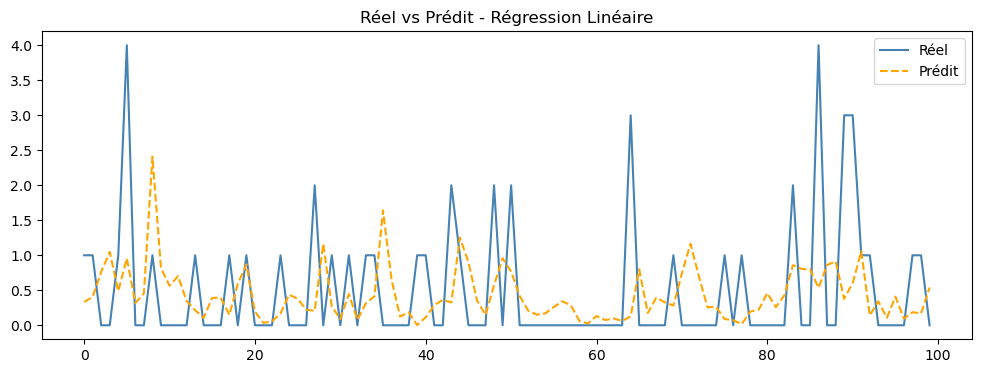

In [104]:
# Régression Linéaire
reg = LinearRegression()
reg.fit(X_train, y_train)
pred_reg = reg.predict(X_test)

print("Régression Linéaire")
print("MAE  :", round(mean_absolute_error(y_test, pred_reg), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_reg)), 3))
print("Biais:", round((y_test.values - pred_reg).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_reg[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Régression Linéaire')
plt.legend()
plt.show()

Arbre de Décision
MAE  : 1.1
RMSE : 2.372
Biais: 0.143


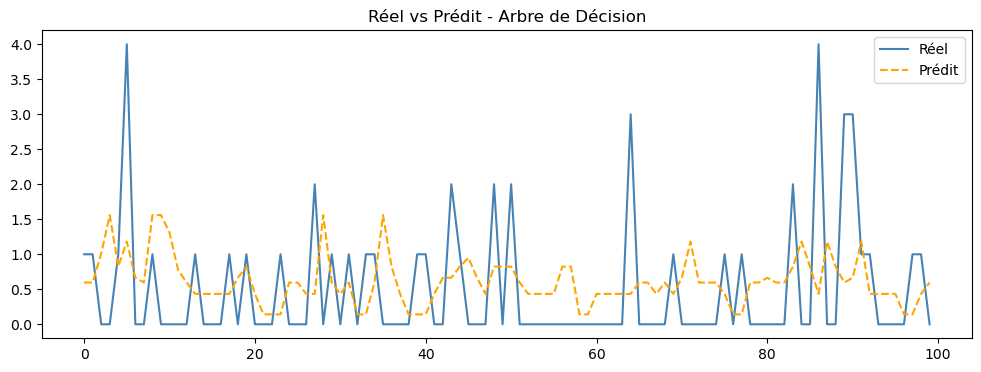

In [105]:
# Arbre de Décision
# max_depth=8 pour éviter le surapprentissage
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

print("Arbre de Décision")
print("MAE  :", round(mean_absolute_error(y_test, pred_dt), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_dt)), 3))
print("Biais:", round((y_test.values - pred_dt).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_dt[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Arbre de Décision')
plt.legend()
plt.show()

Random Forest
MAE  : 1.077
RMSE : 2.134
Biais: 0.133


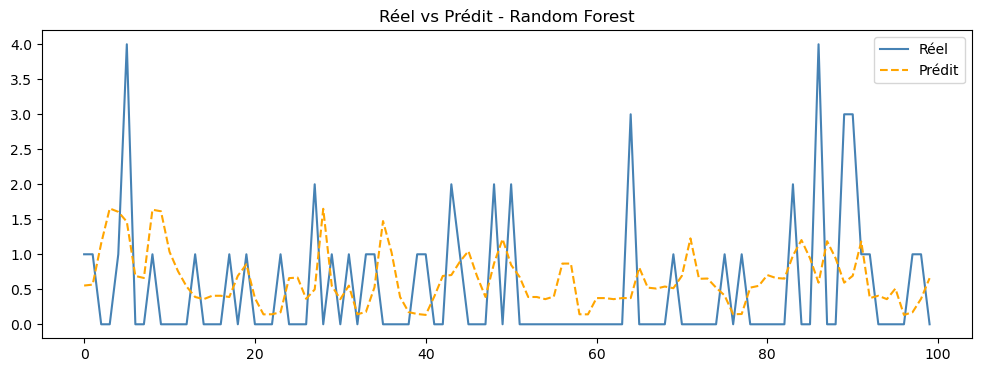

In [106]:
# Random Forest
# 50 arbres par bagging, plus robuste que l'arbre seul
# pas de GridSearchCV car avec 487k lignes ça prendrait des heures
rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE  :", round(mean_absolute_error(y_test, pred_rf), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_rf)), 3))
print("Biais:", round((y_test.values - pred_rf).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_rf[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - Random Forest')
plt.legend()
plt.show()

XGBoost
MAE  : 1.062
RMSE : 2.069
Biais: 0.102


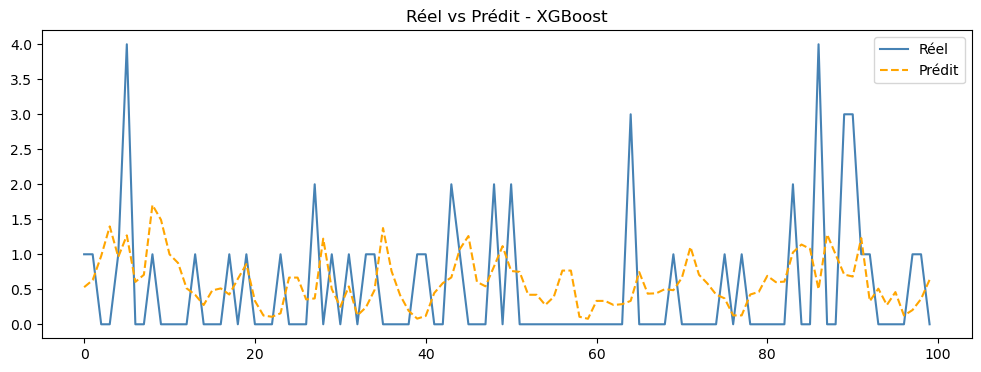

In [107]:
# XGBoost
# boosting par gradient, corrige les erreurs du modèle précédent à chaque étape
xgb_model = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                          random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
pred_xgb = xgb_model.predict(X_test)

print("XGBoost")
print("MAE  :", round(mean_absolute_error(y_test, pred_xgb), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_xgb)), 3))
print("Biais:", round((y_test.values - pred_xgb).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_xgb[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - XGBoost')
plt.legend()
plt.show()

MLP
MAE  : 1.105
RMSE : 2.117
Biais: 0.114


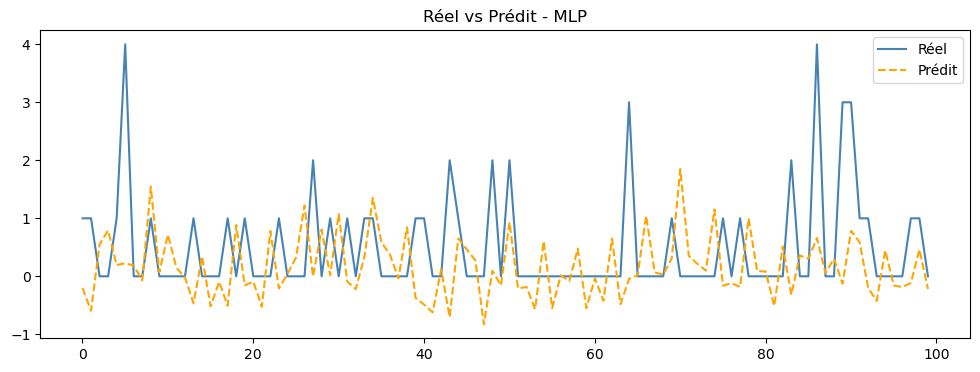

In [108]:
#  MLP
# réseau de neurones, on teste s'il capte des patterns plus complexes
mlp = MLPRegressor(hidden_layer_sizes=(50, 50), activation='relu', max_iter=200, random_state=42)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

print("MLP")
print("MAE  :", round(mean_absolute_error(y_test, pred_mlp), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_mlp)), 3))
print("Biais:", round((y_test.values - pred_mlp).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_mlp[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - MLP')
plt.legend()
plt.show()

LightGBM
MAE  : 0.992
RMSE : 2.146
Biais: 0.52


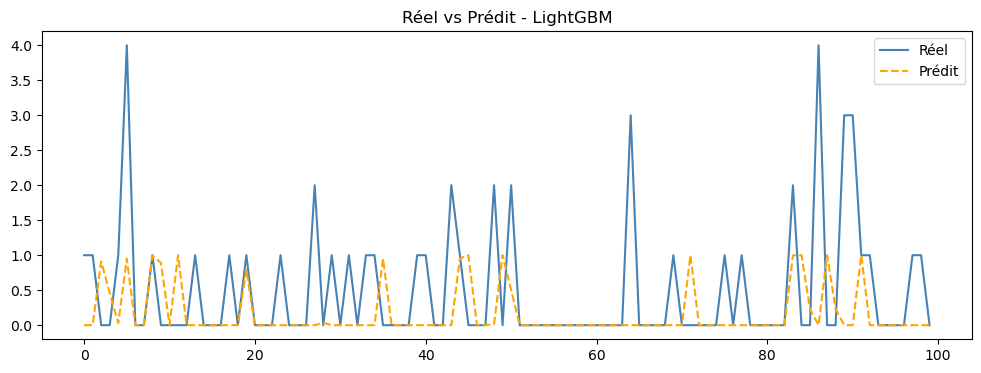

In [109]:
# LightGBM
# variante rapide du boosting, très efficace sur les grands datasets
params = {'objective':'regression_l1', 'metric':'mae', 'learning_rate':0.05,
          'num_leaves':127, 'verbose':-1, 'n_jobs':-1}
lgb_model = lgb.train(params, lgb.Dataset(X_train, y_train), num_boost_round=300,
                       valid_sets=[lgb.Dataset(X_test, y_test)],
                       callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
pred_lgb = lgb_model.predict(X_test)

print("LightGBM")
print("MAE  :", round(mean_absolute_error(y_test, pred_lgb), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_lgb)), 3))
print("Biais:", round((y_test.values - pred_lgb).mean(), 3))

plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:100], label='Réel', color='steelblue')
plt.plot(pred_lgb[:100], label='Prédit', linestyle='--', color='orange')
plt.title('Réel vs Prédit - LightGBM')
plt.legend()
plt.show()

In [110]:
# Tableau comparatif 
resultats = {
    'Modèle Naïf'        : {'MAE': round(mean_absolute_error(y_test, pred_naif), 3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_naif)), 3), 'Biais': round((y_test.values - pred_naif).mean(), 3)},
    'Régression Linéaire': {'MAE': round(mean_absolute_error(y_test, pred_reg),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_reg)),  3), 'Biais': round((y_test.values - pred_reg).mean(),  3)},
    'Arbre de Décision'  : {'MAE': round(mean_absolute_error(y_test, pred_dt),   3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_dt)),   3), 'Biais': round((y_test.values - pred_dt).mean(),   3)},
    'Random Forest'      : {'MAE': round(mean_absolute_error(y_test, pred_rf),   3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_rf)),   3), 'Biais': round((y_test.values - pred_rf).mean(),   3)},
    'XGBoost'            : {'MAE': round(mean_absolute_error(y_test, pred_xgb),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_xgb)),  3), 'Biais': round((y_test.values - pred_xgb).mean(),  3)},
    'LightGBM'           : {'MAE': round(mean_absolute_error(y_test, pred_lgb),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_lgb)),  3), 'Biais': round((y_test.values - pred_lgb).mean(),  3)},
    'MLP'                : {'MAE': round(mean_absolute_error(y_test, pred_mlp),  3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred_mlp)),  3), 'Biais': round((y_test.values - pred_mlp).mean(),  3)}
}

print("COMPARAISON DES MODÈLES")
print(pd.DataFrame(resultats).T.sort_values('MAE'))

COMPARAISON DES MODÈLES
                       MAE   RMSE  Biais
LightGBM             0.992  2.146  0.520
Régression Linéaire  1.046  2.104  0.242
XGBoost              1.062  2.069  0.102
Random Forest        1.077  2.134  0.133
Arbre de Décision    1.100  2.372  0.143
MLP                  1.105  2.117  0.114
Modèle Naïf          1.301  2.683  0.027


## 4. Visualisation des résultats pour soutenance 

même chose que ce qu'on a fait ci-dessus mais en graph pour soutenance car au moins ça saute aux yeux 

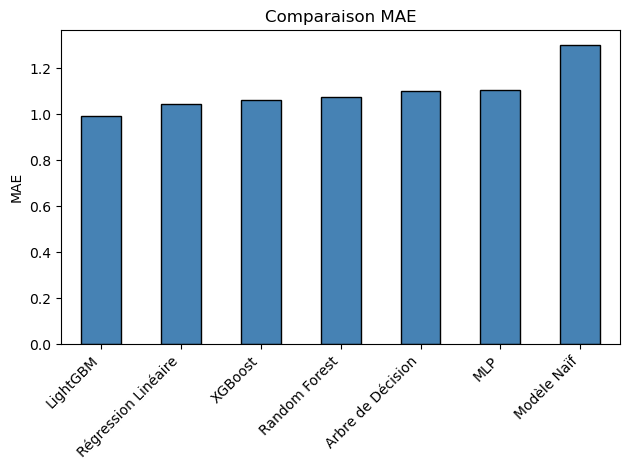

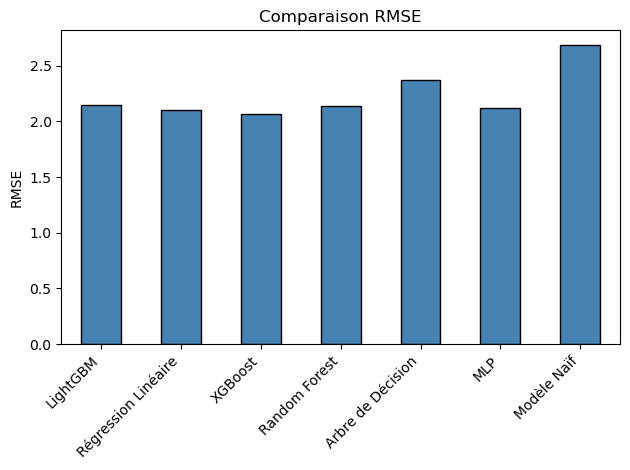

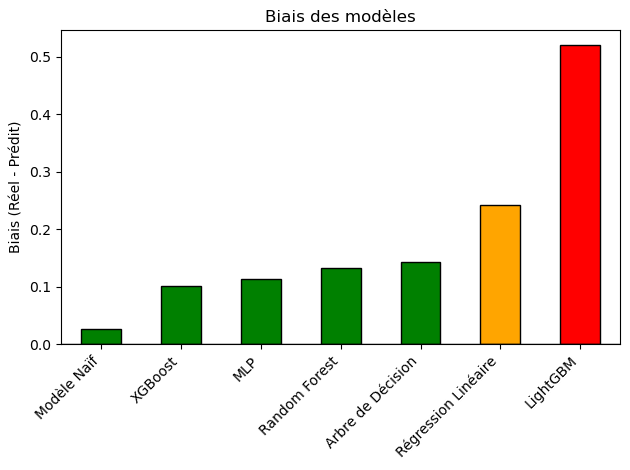

In [111]:
# Comparaison MAE
df_resultats = pd.DataFrame(resultats).T.sort_values('MAE')

df_resultats['MAE'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison MAE')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Comparaison RMSE
df_resultats['RMSE'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Comparaison RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Comparaison Biais
df_biais = df_resultats['Biais'].sort_values()
colors = ['red' if v > 0.3 else 'orange' if v > 0.15 else 'green' for v in df_biais.values]
df_biais.plot(kind='bar', color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1)
plt.title('Biais des modèles')
plt.ylabel('Biais (Réel - Prédit)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

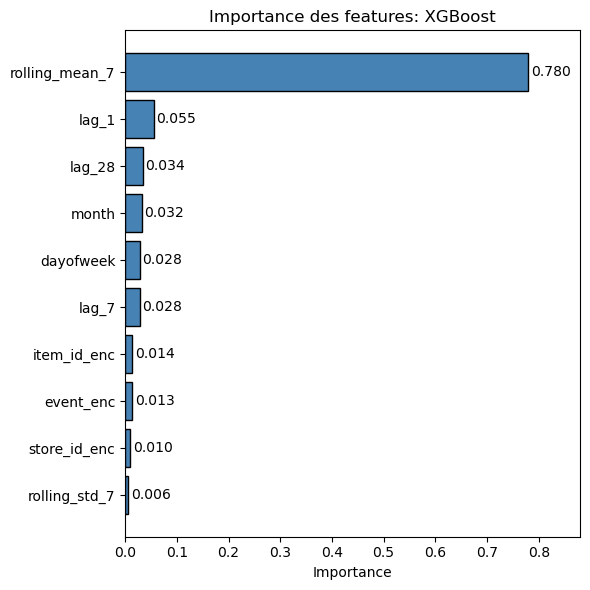

In [112]:
# importance des features XGBoost
fi_xgb = pd.Series(xgb_model.feature_importances_, index=features).sort_values()

plt.figure(figsize=(6, 6))
bars = plt.barh(fi_xgb.index, fi_xgb.values, color='steelblue', edgecolor='black')

# afficher les valeurs sur chaque barre
for bar, val in zip(bars, fi_xgb.values):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Importance des features: XGBoost')
plt.xlabel('Importance')
plt.xlim(0, fi_xgb.max() + 0.1)
plt.tight_layout()
plt.show()

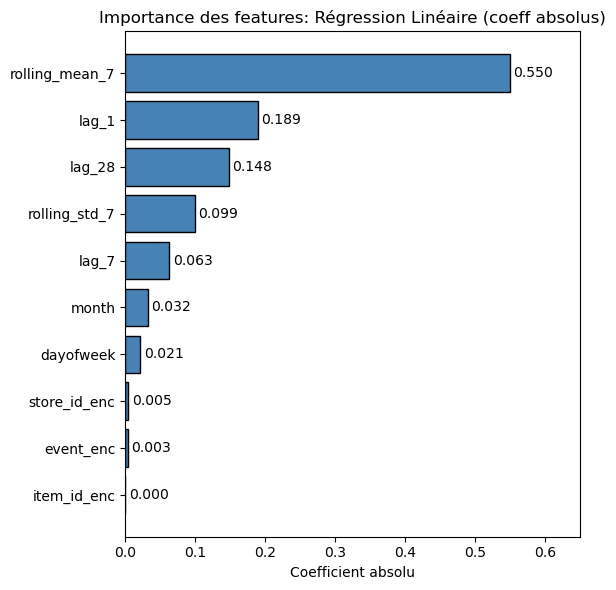

In [113]:
# importance des features Régression Linéaire (valeur absolue des coefficients)
fi_reg = pd.Series(np.abs(reg.coef_), index=features).sort_values()

plt.figure(figsize=(6, 6))
bars = plt.barh(fi_reg.index, fi_reg.values, color='steelblue', edgecolor='black')

# afficher les valeurs sur chaque barre
for bar, val in zip(bars, fi_reg.values):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.title('Importance des features: Régression Linéaire (coeff absolus)')
plt.xlabel('Coefficient absolu')
plt.xlim(0, fi_reg.max() + 0.1)
plt.tight_layout()
plt.show()

**Interprétation de l'importance des features**

Les deux modèles s'accordent : `rolling_mean_7` domine largement (0.780 XGBoost, 
0.550 régression). La moyenne des 7 derniers jours est de loin le meilleur prédicteur, 
cohérent avec sa corrélation de 0.78 dans la matrice.

`lag_1` arrive en 2ème position dans les deux modèles (0.055 XGBoost, 0.189 régression). 
Les ventes d'hier sont un bon prédicteur des ventes d'aujourd'hui.

`rolling_std_7` est plus utile en régression (0.099) qu'en XGBoost (0.006). 
La régression utilise la variabilité des ventes récentes comme signal direct, 
XGBoost la capte indirectement via ses interactions non linéaires.

La différence clé entre les deux modèles :
- `item_id_enc` → 0.014 dans XGBoost mais 0.000 en régression. 
  La régression ne différencie pas les produits entre eux, XGBoost oui.
- `event_enc` → 0.013 dans XGBoost mais 0.003 en régression. 
  XGBoost capte mieux l'impact des événements.

`store_id_enc` reste faible dans les deux (0.010 XGBoost, 0.005 régression) 
car les lags calculés par magasin captent déjà implicitement l'information magasin.

Ces résultats confirment le choix de XGBoost : c'est le seul modèle qui utilise 
réellement l'information produit et événement, indispensables pour prédire 
par produit dans chaque magasin pour Sophie Martin.

## Conclusion générale

### Comparaison des modèles et choix final

Tous les modèles dépassent le modèle naïf (MAE=1.301), ce qui confirme qu'ils 
apportent tous une valeur ajoutée par rapport à "demain = il y a 7 jours".

Sur le MAE seul LightGBM semble le meilleur (0.992). Cependant son biais est le 
plus fort de tous les modèles (0.520) : il sous-estime systématiquement les ventes 
de 0.520 unités par produit par jour. Dans un contexte supply chain sous-estimer 
mène directement à des ruptures de stock.

XGBoost a un MAE légèrement moins bon (1.062) mais le biais le plus faible (0.102), 
soit 58% de moins que la régression linéaire. Il obtient également le meilleur RMSE 
(2.069), ce qui confirme qu'il gère mieux les pics de ventes que les autres modèles.

**On retient XGBoost comme modèle final** car c'est le seul qui combine un MAE 
acceptable, le meilleur RMSE et le biais le plus faible. Un biais de 0.102 signifie 
que le modèle ne sur-commande ni ne sous-commande systématiquement, ce qui est 
exactement ce dont Sophie Martin a besoin pour gérer ses stocks.



### Le choix des données d'entraînement

Ce résultat n'a pas été obtenu directement. Nous avons testé plusieurs approches 
avant de trouver la plus cohérente.

**Première approche: 180 jours :**
On a commencé par les 180 derniers jours du dataset. Le modèle donnait un biais 
de 0.155 et un MAE de 1.072, des résultats corrects. Mais avec seulement 16 dates 
continues disponibles la prévision récursive à 14 et 28 jours accumulait les erreurs.

**Deuxième approche: Top 300 produits + toutes les dates :**
Pour avoir plus de dates continues on a filtré sur les 300 produits les plus vendus 
en gardant toutes les 1941 dates disponibles. Cela permettait théoriquement d'entraîner 
3 modèles par horizon (J+7, J+14, J+28) sans prévision récursive.

Mais les résultats étaient instables : le biais passait de -1.27 sur J+7 à +4.051 
sur J+14. Un biais de 4 unités par produit par jour sur 14 jours est inacceptable 
pour la supply chain. De plus le modèle optimal devenait Random Forest au lieu 
de XGBoost, remettant en question tout le travail déjà fait.

**Décision finale: 270 jours :**
On est revenu à une approche intermédiaire avec 270 jours. Par rapport aux 180 jours :
- MAE passe de 1.072 à 1.062 
- RMSE passe de 2.133 à 2.069 
- Biais passe de 0.155 à 0.102 

Les résultats sont meilleurs et surtout stables. La prévision récursive reste 
nécessaire pour les horizons 14 et 28 jours avec un avertissement dans le Streamlit, 
mais le biais stable de 0.102 limite l'accumulation des erreurs.

La prévision directe multi-horizons n'était pas faisable avec 270 jours car 
le shift(-28) donnait 0% de données utilisables, confirmant que le dataset M5 
est trop sparse pour cette approche avec notre contrainte de volume.

### Distribution des erreurs - Régression Linéaire

On analyse la distribution des erreurs du modèle retenu pour vérifier qu'il est bien calibré, un pic centré sur 0 indique que le modèle n'est pas biaisé.

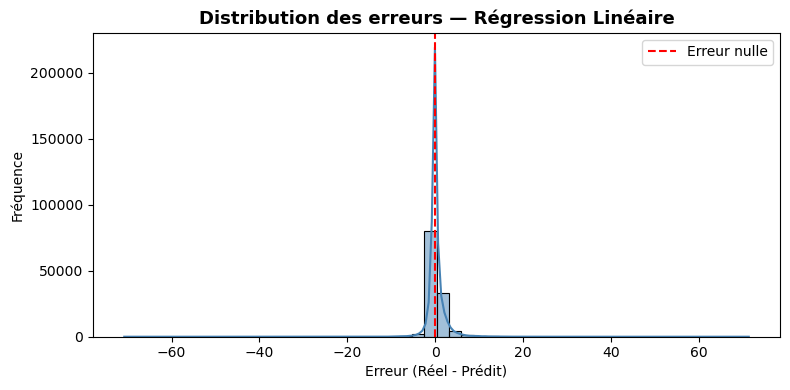

Erreur moyenne : 0.242
Ecart-type des erreurs : 2.090


In [114]:
errors = y_test.values - reg.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — Régression Linéaire', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors.mean():.3f}")
print(f"Ecart-type des erreurs : {errors.std():.3f}")

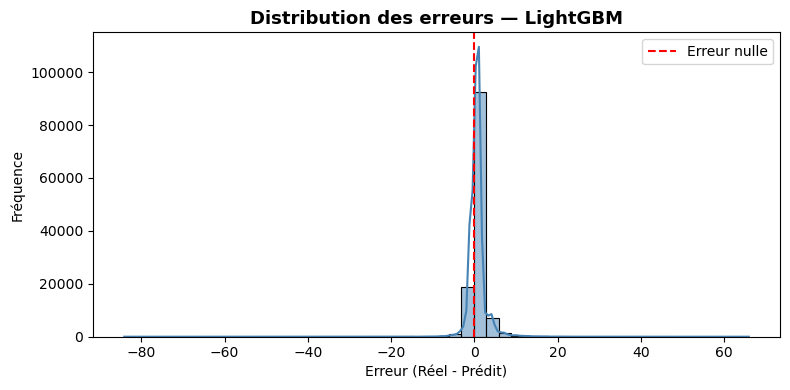

Erreur moyenne : 0.520
Ecart-type des erreurs : 2.082


In [116]:
# Distribution des erreurs - LightGBM
errors_lgbm = y_test.values - lgb_model.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors_lgbm, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — LightGBM', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors_lgbm.mean():.3f}")
print(f"Ecart-type des erreurs : {errors_lgbm.std():.3f}")

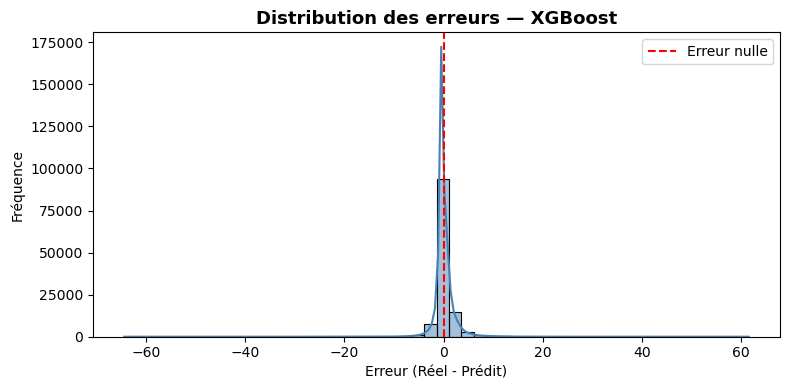

Erreur moyenne : 0.102
Ecart-type des erreurs : 2.066


In [63]:
# Distribution des erreurs - XGBoost
errors_xgb = y_test.values - xgb_model.predict(X_test)

plt.figure(figsize=(8, 4))
sns.histplot(errors_xgb, bins=50, kde=True, color='steelblue')
plt.title('Distribution des erreurs — XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Erreur (Réel - Prédit)')
plt.ylabel('Fréquence')
plt.axvline(0, color='red', linestyle='--', label='Erreur nulle')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erreur moyenne : {errors_xgb.mean():.3f}")
print(f"Ecart-type des erreurs : {errors_xgb.std():.3f}")

In [92]:
# Entraînement Random Forest pour les 3 horizons
# Prévision directe sans récursive — chaque modèle apprend à prédire son horizon

# Suppression des NaN pour chaque cible
train_7  = train[y_train_7.notna()]
train_14 = train[y_train_14.notna()]
train_28 = train[y_train_28.notna()]

X_train_7  = train_7[features]
X_train_14 = train_14[features]
X_train_28 = train_28[features]

y_train_7_clean  = y_train_7[y_train_7.notna()]
y_train_14_clean = y_train_14[y_train_14.notna()]
y_train_28_clean = y_train_28[y_train_28.notna()]

# Random Forest J+7
rf_7 = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_7.fit(X_train_7, y_train_7_clean)
pred_rf_7 = rf_7.predict(X_test)
print("Random Forest J+7")
print("MAE  :", round(mean_absolute_error(y_test, pred_rf_7), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_rf_7)), 3))
print("Biais:", round((y_test.values - pred_rf_7).mean(), 3))

# Random Forest J+14
rf_14 = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_14.fit(X_train_14, y_train_14_clean)
pred_rf_14 = rf_14.predict(X_test)
print("\nRandom Forest J+14")
print("MAE  :", round(mean_absolute_error(y_test, pred_rf_14), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_rf_14)), 3))
print("Biais:", round((y_test.values - pred_rf_14).mean(), 3))

# Random Forest J+28
rf_28 = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_28.fit(X_train_28, y_train_28_clean)
pred_rf_28 = rf_28.predict(X_test)
print("\nRandom Forest J+28")
print("MAE  :", round(mean_absolute_error(y_test, pred_rf_28), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test, pred_rf_28)), 3))
print("Biais:", round((y_test.values - pred_rf_28).mean(), 3))

Random Forest J+7
MAE  : 8.414
RMSE : 11.621
Biais: -1.27

Random Forest J+14
MAE  : 9.694
RMSE : 13.813
Biais: 4.051

Random Forest J+28
MAE  : 10.45
RMSE : 14.407
Biais: 0.412


## 6. Export du modèle pour le Streamlit

On sauvegarde le modèle final et les fichiers nécessaires pour que le Streamlit puisse les charger directement sans réentraîner le modèle à chaque fois.

In [117]:
import joblib
import os

# Sauvegarde sur le Bureau
dossier = '/Users/maelys_thr/Desktop/Modeles_Magasins'
os.makedirs(dossier, exist_ok=True)

# Sauvegarde du modèle XGBoost final
joblib.dump(xgb_model, f'{dossier}/modele_xgboost_magasins.pkl')

# Sauvegarde des features
joblib.dump(features, f'{dossier}/features_magasins.pkl')

# Sauvegarde du LabelEncoder pour item_id
joblib.dump(le, f'{dossier}/label_encoder_magasins.pkl')

# Sauvegarde du MAE global
joblib.dump(round(mean_absolute_error(y_test, xgb_model.predict(X_test)), 3),
            f'{dossier}/mae_magasins.pkl')

# Sauvegarde des données test avec prédictions
test_save = test[['date', 'store_id', 'item_id', 'sales']].copy()
test_save['prediction'] = xgb_model.predict(X_test)
test_save.to_csv(f'{dossier}/test_predictions_magasins.csv', index=False)

# Sauvegarde du MAE par magasin
mae_par_magasin = test.groupby('store_id').apply(
    lambda g: mean_absolute_error(g['sales'], xgb_model.predict(g[features]))
).round(3)
joblib.dump(mae_par_magasin, f'{dossier}/mae_par_magasin.pkl')

# Sauvegarde des données complètes pour les prévisions futures
joblib.dump(df_long, f'{dossier}/df_long_magasins.pkl')

print("Fichiers sauvegardés sur le Bureau dans Modeles_Magasins")

Fichiers sauvegardés sur le Bureau dans Modeles_Magasins


In [118]:
print("Dernière colonne :", day_cols[-1])
print("Date correspondante :", calendar[calendar['d'] == day_cols[-1]]['date'].values[0])

Dernière colonne : d_1941
Date correspondante : 2016-05-22T00:00:00.000000000


In [119]:
calendar[calendar['event_name_1'].str.contains('Mother', na=False)][['date', 'event_name_1']]

,date,event_name_1
99,2011-05-08,Mother's day
470,2012-05-13,Mother's day
834,2013-05-12,Mother's day
1198,2014-05-11,Mother's day
1562,2015-05-10,Mother's day
1926,2016-05-08,Mother's day


In [120]:
# Dans le notebook
print("MAE par magasin :")
print(mae_par_magasin)

MAE par magasin :
store_id
CA_1    1.167
CA_2    1.228
CA_3    1.366
CA_4    0.819
TX_1    0.892
TX_2    0.980
TX_3    0.978
WI_1    1.030
WI_2    1.183
WI_3    0.983
dtype: float64


In [121]:
# Vérification 1 — MAE par magasin cohérent avec le global
print("MAE global :", round(mean_absolute_error(y_test, pred_xgb), 3))
print("MAE par magasin :")
print(mae_par_magasin.sort_values())

# Vérification 2 — Les alertes sont cohérentes avec l'exploration
store_recent = df_long[df_long['store_id'] == 'CA_2'].groupby('date')['sales'].sum()
print("\nMoyenne journalière CA_2 :", round(store_recent.mean(), 0))
print("Memorial Day +20% :", round(store_recent.mean() * 0.20, 0), "unités")
print("Father's Day +27% :", round(store_recent.mean() * 0.27, 0), "unités")

# Vérification 3 — Prévision cohérente avec historique
print("\nMoyenne ventes réelles CA_2 :", round(store_recent.mean(), 0))

MAE global : 1.062
MAE par magasin :
store_id
CA_4    0.819
TX_1    0.892
TX_3    0.978
TX_2    0.980
WI_3    0.983
WI_1    1.030
CA_1    1.167
WI_2    1.183
CA_2    1.228
CA_3    1.366
dtype: float64

Moyenne journalière CA_2 : 4059.0
Memorial Day +20% : 812.0 unités
Father's Day +27% : 1096.0 unités

Moyenne ventes réelles CA_2 : 4059.0


In [122]:
print("Dates dans le test :")
print(sorted(test['date'].unique()))
print("Nombre de dates :", test['date'].nunique())

Dates dans le test :
[Timestamp('2016-04-30 00:00:00'), Timestamp('2016-05-01 00:00:00'), Timestamp('2016-05-05 00:00:00'), Timestamp('2016-05-08 00:00:00')]
Nombre de dates : 4


In [123]:
split = int(len(df_long) * 0.8)
print("Période train :", df_long['date'].iloc[:split].min().date(), "au", df_long['date'].iloc[:split].max().date())
print("Période test  :", df_long['date'].iloc[split:].min().date(), "au", df_long['date'].iloc[split:].max().date())
print("Dates uniques test :", df_long['date'].iloc[split:].nunique())

Période train : 2015-09-24 au 2016-05-08
Période test  : 2015-09-24 au 2016-05-08
Dates uniques test : 22


In [3]:
import pandas as pd

sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')

day_cols = [c for c in sales.columns if c.startswith('d_')]

print(f"Lignes totales avec toutes les dates : {sales.shape[0] * len(day_cols):,}")

Lignes totales avec toutes les dates : 59,181,090


In [4]:
print(f"Lignes avec 365 jours : {sales.shape[0] * 365:,}")

Lignes avec 365 jours : 11,128,850


In [5]:
day_cols_365 = day_cols[-365:]
last_d = day_cols_365[-1]
cutoff_d = day_cols_365[int(len(day_cols_365) * 0.8)]

last_date_365 = calendar[calendar['d'] == last_d]['date'].values[0]
cutoff_date_365 = calendar[calendar['d'] == cutoff_d]['date'].values[0]

df_test_365 = calendar[(calendar['date'] > cutoff_date_365) & (calendar['date'] <= last_date_365)]
print("Dates disponibles dans le test :", df_test_365['date'].nunique())

Dates disponibles dans le test : 72


In [6]:
import psutil
ram_disponible = psutil.virtual_memory().available / 1024**3
print(f"RAM disponible : {ram_disponible:.1f} GB")

RAM disponible : 1.5 GB


In [8]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

df_long  = joblib.load('/Users/maelys_thr/Desktop/Modeles_Magasins/df_long_magasins.pkl')
features = joblib.load('/Users/maelys_thr/Desktop/Modeles_Magasins/features_magasins.pkl')

split        = int(len(df_long) * 0.8)
X_train_8020 = df_long[features].iloc[:split]
X_test_8020  = df_long[features].iloc[split:]
y_train_8020 = df_long['sales'].iloc[:split]
y_test_8020  = df_long['sales'].iloc[split:]

xgb_test = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         random_state=42, n_jobs=-1, verbosity=0)
xgb_test.fit(X_train_8020, y_train_8020)
pred_test = xgb_test.predict(X_test_8020)

print("MAE  :", round(mean_absolute_error(y_test_8020, pred_test), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test_8020, pred_test)), 3))
print("Biais:", round((y_test_8020.values - pred_test).mean(), 3))
print("Dates uniques test :", df_long['date'].iloc[split:].nunique())

MAE  : 0.552
RMSE : 0.974
Biais: -0.069
Dates uniques test : 22
